In [57]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.datasets import MNIST
from torchvision.transforms import transforms
from torch.utils.data import DataLoader
from torch.optim import Adam
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [58]:
torch.manual_seed(42)

In [59]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

train_dataset = MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = MNIST(root='./data', train=False, download=True, transform=transform)

len(train_dataset)
len(test_dataset)

60000

10000

In [60]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                          pin_memory=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False,
                         pin_memory=False, num_workers=0)

len(train_loader)
len(test_loader)

images, labels = next(iter(train_loader))

labels[:10]

1875

313

tensor([1, 2, 8, 5, 2, 6, 9, 9, 9, 4])

In [61]:
class MLP(nn.Module):
  def __init__(self):
    super(MLP, self).__init__()

    self.fc1 = nn.Linear(784, 128)
    self.fc2 = nn.Linear(128, 64)
    self.fc3 = nn.Linear(64, 10)
    self.dropout = nn.Dropout(0.20)

  def forward(self, x):
    x = x.view(x.size(0), -1)  # [32, 1, 28, 28] => [32, 784]

    x = F.relu(self.fc1(x))
    x = self.dropout(x)

    x = F.relu(self.fc2(x))
    x = self.dropout(x)

    return self.fc3(x)

In [62]:
model = nn.Sequential(
    nn.Flatten(),

    # Layer 1
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Dropout(0.20),

    # Layer 2
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Dropout(0.20),

    # Layer 3
    nn.Linear(64, 10)
)

total = 0
for name, param in model.named_parameters():
  total += param.numel()
  print(f'{name:10s} | {tuple(param.shape)}')

print(f'total params: {total}')

1.weight   | (128, 784)
1.bias     | (128,)
4.weight   | (64, 128)
4.bias     | (64,)
7.weight   | (10, 64)
7.bias     | (10,)
total params: 109386


In [63]:
next(iter(model.parameters())).flatten()[:10]

tensor([-0.0078,  0.0072, -0.0174,  0.0210,  0.0315, -0.0262,  0.0310,  0.0067,
         0.0264,  0.0048], grad_fn=<SliceBackward0>)

In [64]:
criterion = nn.CrossEntropyLoss()

optimizer = Adam(model.parameters(), lr=0.0001)

In [65]:
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

NUM_EPOCHS = 10

for epoch in range(NUM_EPOCHS):
  print(f'THIS IS EPOCH {epoch}')

  # training phase
  train_loss_lst = []
  train_acc_lst = []

  print('  Training phase')
  _ = model.train()
  for batch_idx, (images, labels) in enumerate(train_loader):
    # 1. clear accumulated grads
    optimizer.zero_grad()

    # 2. forward pass to generate outputs
    outputs = model(images)

    # 3. calculate loss using criterion
    loss = criterion(outputs, labels)

    # 4. backward pass to calculate grads
    loss.backward()

    # 5. update model params
    optimizer.step()

    labels_pred = torch.max(outputs, dim=1).indices
    train_acc = accuracy_score(labels, labels_pred)
    train_acc_lst.append(train_acc)
    train_loss_lst.append(loss.item())

    if batch_idx % 200 == 0:
      print(f'  batch {batch_idx:>4}, loss {loss:.4f}, acc {train_acc:.4f}')

  # validation phase
  val_acc_lst = []
  val_loss_lst = []

  print('  Validation phase')
  _ = model.eval()
  with torch.no_grad():
    for batch_idx, (images, labels) in enumerate(test_loader):
      outputs = model(images)
      loss = criterion(outputs, labels)

      labels_pred = torch.max(outputs, dim=1).indices
      val_acc = accuracy_score(labels, labels_pred)
      val_acc_lst.append(val_acc)
      val_loss_lst.append(loss.item())

      if batch_idx % 200 == 0:
        print(f'  batch {batch_idx:>4}, loss {loss:.4f}, acc {val_acc:.4f}')

  history['train_acc'].append(np.mean(train_acc_lst))
  history['train_loss'].append(np.mean(train_loss_lst))
  history['val_acc'].append(np.mean(val_acc_lst))
  history['val_loss'].append(np.mean(val_loss_lst))

THIS IS EPOCH 0
  Training phase
  batch    0, loss 2.3073, acc 0.0625
  batch  200, loss 1.3915, acc 0.5938
  batch  400, loss 0.7308, acc 0.8750
  batch  600, loss 0.6993, acc 0.7500
  batch  800, loss 0.4516, acc 0.8750
  batch 1000, loss 0.8503, acc 0.7500
  batch 1200, loss 0.5744, acc 0.7812
  batch 1400, loss 0.3735, acc 0.9375
  batch 1600, loss 0.3808, acc 0.9062
  batch 1800, loss 0.4248, acc 0.8750
  Validation phase
  batch    0, loss 0.2465, acc 0.9688
  batch  200, loss 0.3246, acc 0.8750
THIS IS EPOCH 1
  Training phase
  batch    0, loss 0.2872, acc 0.9062
  batch  200, loss 0.4169, acc 0.8750
  batch  400, loss 0.3513, acc 0.8750
  batch  600, loss 0.2548, acc 0.9375
  batch  800, loss 0.5807, acc 0.8750
  batch 1000, loss 0.1081, acc 0.9688
  batch 1200, loss 0.5640, acc 0.8438
  batch 1400, loss 0.3947, acc 0.8125
  batch 1600, loss 0.4786, acc 0.8438
  batch 1800, loss 0.2233, acc 0.9688
  Validation phase
  batch    0, loss 0.2142, acc 0.9688
  batch  200, loss 0.2

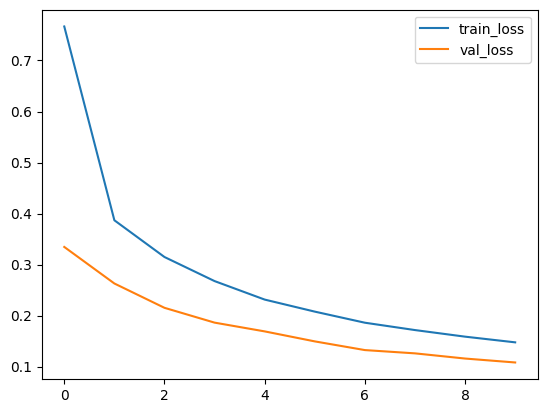

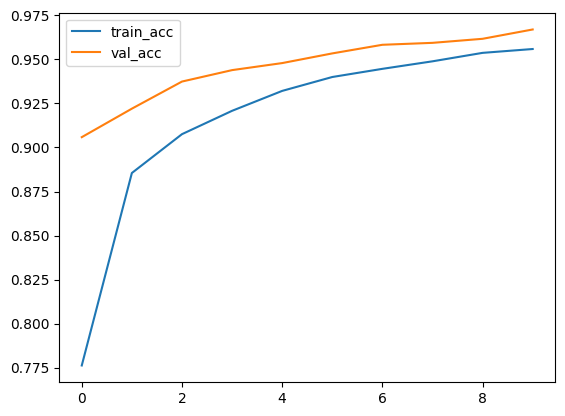

In [66]:
_ = plt.plot(history['train_loss'], label='train_loss')
_ = plt.plot(history['val_loss'], label='val_loss')
_ = plt.legend()
plt.show()

_ = plt.plot(history['train_acc'], label='train_acc')
_ = plt.plot(history['val_acc'], label='val_acc')
_ = plt.legend()

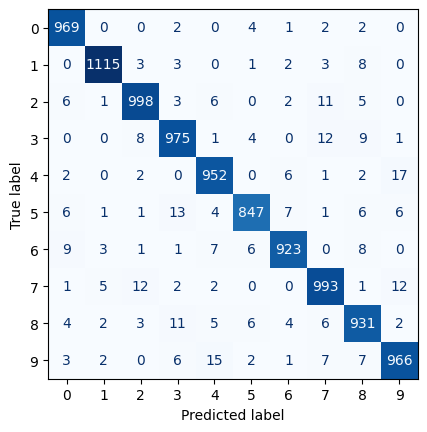

In [67]:
_ = model.eval()

all_labels = []
all_labels_pred = []

with torch.no_grad():
  for images, labels in test_loader:
    outputs = model(images)
    labels_pred = torch.max(outputs, dim=1).indices
    all_labels.extend(labels)
    all_labels_pred.extend(labels_pred)

cm = confusion_matrix(all_labels, all_labels_pred)
cmd = ConfusionMatrixDisplay(cm)
_ = cmd.plot(cmap='Blues', colorbar=False)

In [69]:
torch.save(model.state_dict(), 'mnist-model.pth')

In [73]:
img, label = train_dataset[4000]
img.shape
label
img.unsqueeze(0)

torch.Size([1, 28, 28])

7

tensor([[[[-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
          [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
          [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
          [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.000